# 📱 Predicting Stress from Digital Habits

---

## 🗂️ What This Notebook Covers

| # | Section | What We Do |
|---|---------|------------|
| 1 | 📦 Import Libraries | Load all the Python tools we need |
| 2 | 📂 Load Dataset | Read the CSV and peek at the data |
| 3 | 🔍 Exploratory Data Analysis | Understand patterns with charts |
| 4 | 🧪 Feature Engineering | Create a meaningful target variable |
| 5 | 🛠️ Preprocessing | Prepare data for the ML model |
| 6 | 🤖 Build ML Model | Train a Random Forest Classifier |
| 7 | 📊 Model Evaluation | Check accuracy & confusion matrix |
| 8 | 🔑 Feature Importance | See what drives the predictions |
| 9 | ✅ Conclusion | Key takeaways |

---

### 🎯 Goal
> **Classify users as `Healthy`, `Moderate`, or `At Risk` based on their daily digital habits — screen time, sleep, exercise, and social media usage.**

### 📋 Dataset Info
- **Rows:** 11,000 users  
- **Columns:** 10 features (age, sleep, screen time, exercise, etc.)  
- **No missing values!** 🎉

### 💡 Key Concept — Feature Engineering
The original dataset is **synthetic** (randomly generated), so the raw `stress_level` column has no real pattern.
A key data science skill is **engineering a meaningful target** from domain knowledge — that's exactly what we do here!  
We create a **Digital Wellness Score** by combining healthy/unhealthy factors logically.

---
## 📦 Step 1 — Import Libraries

We load all the Python libraries we need before anything else.

| Library | What it does |
|---------|-------------|
| `pandas` | Read & manipulate tables of data |
| `numpy` | Fast math on arrays |
| `matplotlib / seaborn` | Draw charts and graphs |
| `sklearn` | Everything we need for Machine Learning |

In [1]:
# ── Data Tools ────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)

# ── Settings ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## 📂 Step 2 — Load & Preview the Dataset

> 💡 `df.head()` shows the first 5 rows — always a good starting point!
> `df.describe()` gives quick stats (min, max, mean, etc.) for every number column.

In [2]:
# Load the dataset
df = pd.read_csv('social_media_sleep_stress_productivity_11000.csv')

print(f'📊 Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\n🔍 First 5 rows:')
df.head()

📊 Dataset shape: 11,000 rows × 10 columns

🔍 First 5 rows:


,user_id,age,daily_screen_time_hours,social_media_hours,sleep_hours,exercise_minutes,study_work_hours,productivity_score,stress_level,platform
0,1,44,2.39,1.93,8.46,61,3.73,33.86,Low,YouTube
1,2,30,7.22,5.24,7.34,28,6.80,85.32,Low,YouTube
2,3,23,2.56,4.64,4.69,8,4.47,60.07,High,YouTube
3,4,36,8.75,4.89,5.05,53,9.53,36.46,Medium,LinkedIn
4,5,34,10.96,2.77,7.12,83,7.01,32.93,Medium,Instagram


In [3]:
# Check data types and missing values
print('📋 Column Data Types:')
print(df.dtypes)
print()
print('❓ Missing Values per Column:')
print(df.isnull().sum())

📋 Column Data Types:
user_id                      int64
age                          int64
daily_screen_time_hours    float64
social_media_hours         float64
sleep_hours                float64
exercise_minutes             int64
study_work_hours           float64
productivity_score         float64
stress_level                   str
platform                       str
dtype: object

❓ Missing Values per Column:
user_id                    0
age                        0
daily_screen_time_hours    0
social_media_hours         0
sleep_hours                0
exercise_minutes           0
study_work_hours           0
productivity_score         0
stress_level               0
platform                   0
dtype: int64


In [4]:
# Quick statistics for all numeric columns
print('📈 Basic Statistics:')
df.describe().round(2)

📈 Basic Statistics:


,user_id,age,daily_screen_time_hours,social_media_hours,sleep_hours,exercise_minutes,study_work_hours,productivity_score
count,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00
mean,5500.50,32.56,6.56,4.25,5.99,59.47,5.54,50.62
std,3175.57,9.69,3.18,2.16,1.73,34.72,2.59,28.84
min,1.00,16.00,1.00,0.50,3.00,0.00,1.00,1.00
25%,2750.75,24.00,3.81,2.38,4.50,29.00,3.31,25.73
50%,5500.50,33.00,6.57,4.25,6.00,59.00,5.56,50.22
75%,8250.25,41.00,9.33,6.10,7.49,89.00,7.82,76.23
max,11000.00,49.00,12.00,8.00,9.00,119.00,10.00,99.99


---
## 🔍 Step 3 — Exploratory Data Analysis (EDA)

**EDA = exploring data visually** to find patterns before building any model.

> 💡 Think of EDA as your "getting to know the data" phase — never skip it!

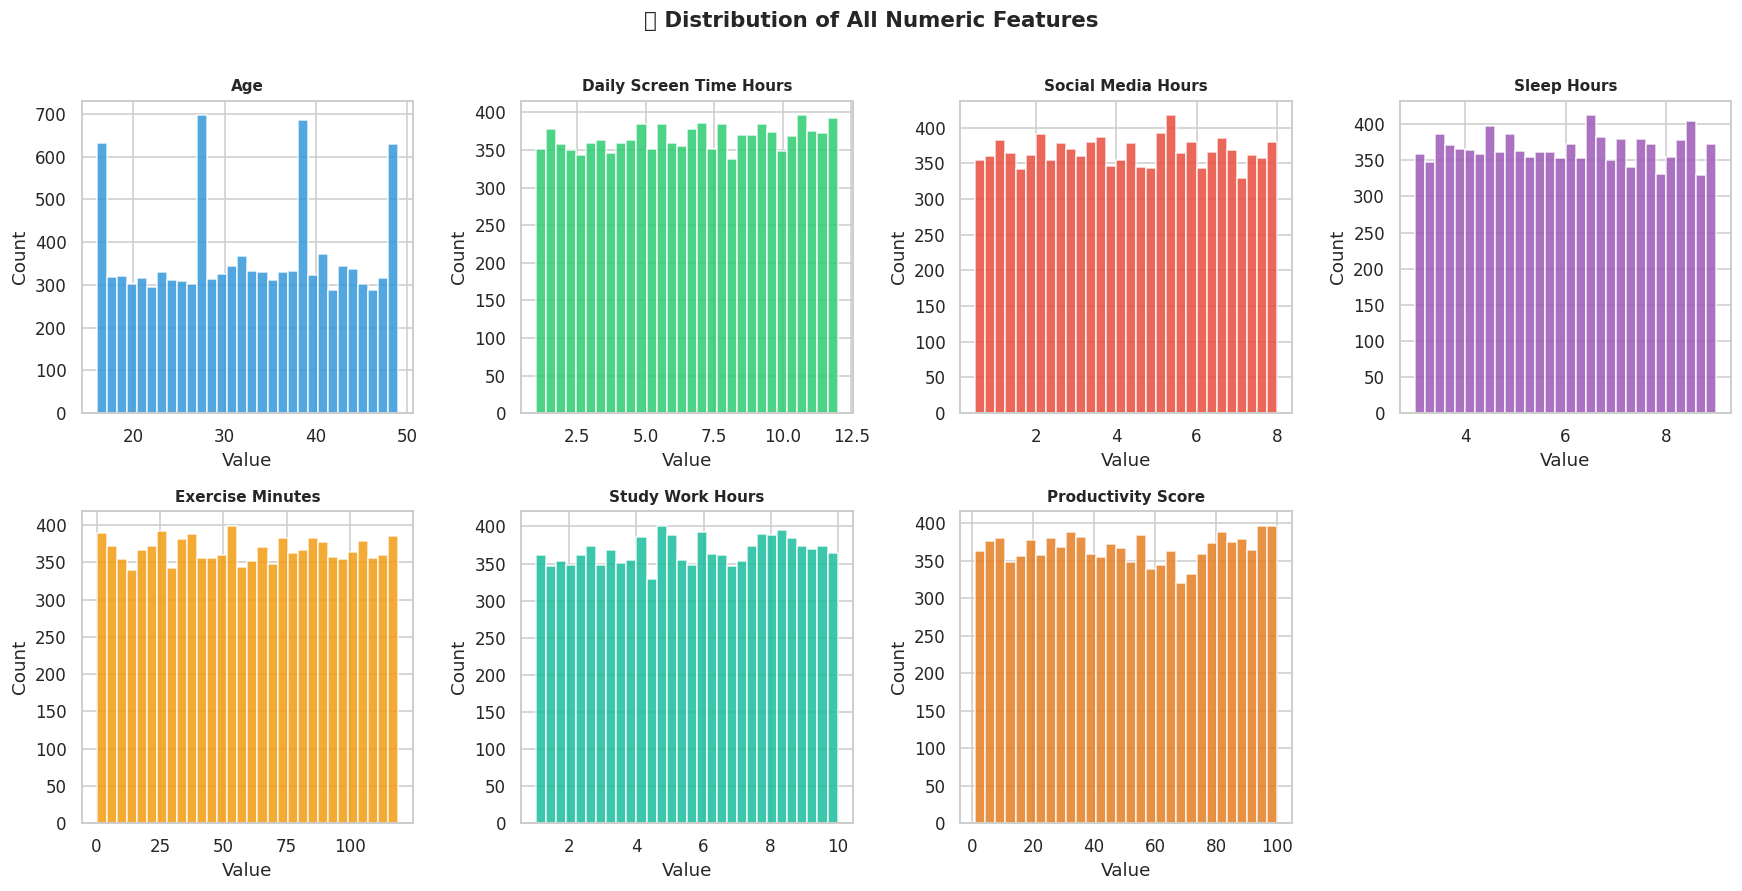

💡 Most features are uniformly distributed — confirming this is a synthetic dataset.


In [5]:
# ── 3.1  Distribution of All Numeric Columns ─────────────────────
numeric_cols = ['age', 'daily_screen_time_hours', 'social_media_hours',
                'sleep_hours', 'exercise_minutes',
                'study_work_hours', 'productivity_score']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

palette_hist = ['#3498db','#2ecc71','#e74c3c','#9b59b6',
                '#f39c12','#1abc9c','#e67e22']

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color=palette_hist[i],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].axis('off')  # Hide unused subplot

plt.suptitle('📈 Distribution of All Numeric Features',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Most features are uniformly distributed — confirming this is a synthetic dataset.')

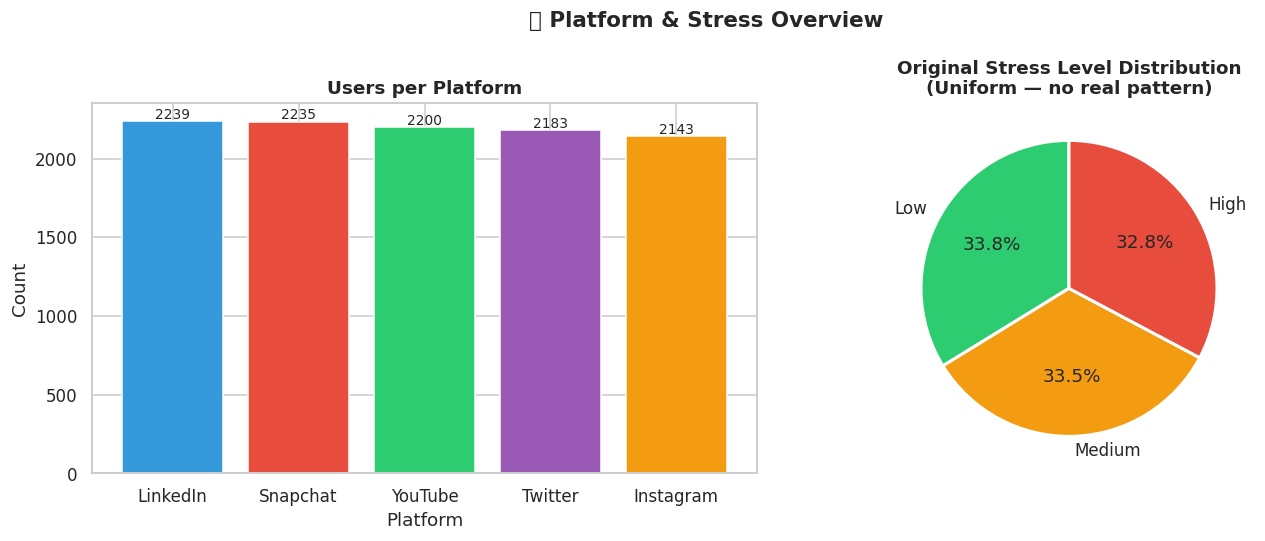

In [6]:
# ── 3.2  Platform Usage & Stress Level Distributions ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Platform counts
plat_counts = df['platform'].value_counts()
axes[0].bar(plat_counts.index, plat_counts.values,
            color=['#3498db','#e74c3c','#2ecc71','#9b59b6','#f39c12'],
            edgecolor='white')
axes[0].set_title('Users per Platform', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].text(p.get_x()+p.get_width()/2, p.get_height()+15,
                 str(int(p.get_height())), ha='center', fontsize=9)

# Stress level counts
stress_counts = df['stress_level'].value_counts()
colors_s = ['#2ecc71','#f39c12','#e74c3c']
axes[1].pie(stress_counts.values, labels=stress_counts.index,
            autopct='%1.1f%%', colors=colors_s, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Original Stress Level Distribution\n(Uniform — no real pattern)',
                  fontsize=12, fontweight='bold')

plt.suptitle('📱 Platform & Stress Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

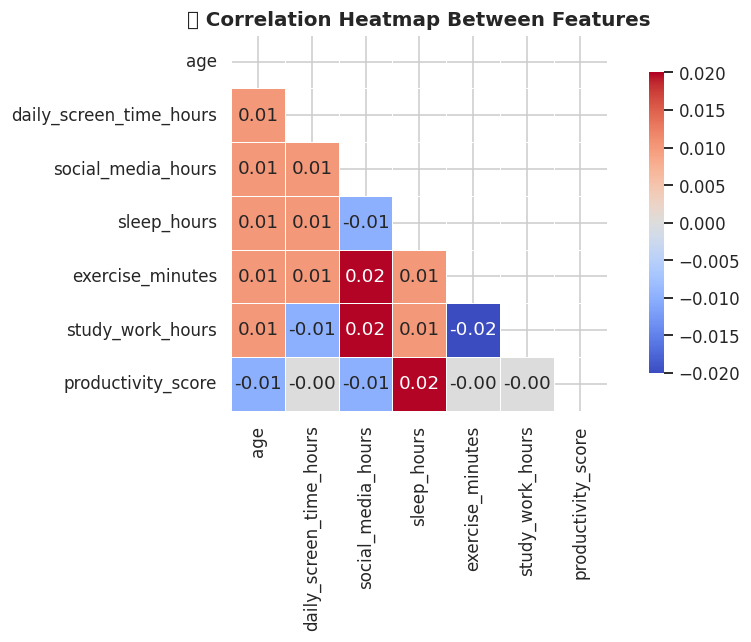

💡 Near-zero correlations confirm the synthetic nature of the dataset.
   This is why we need to ENGINEER a meaningful target variable in Step 4!


In [7]:
# ── 3.3  Correlation Heatmap ──────────────────────────────────────
# Shows how numeric columns relate to each other
# Values close to 1 = strong positive relationship
# Values close to -1 = strong negative relationship
# Values near 0 = no relationship

corr = df[numeric_cols].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))  # Only show lower triangle

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', mask=mask,
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('🔥 Correlation Heatmap Between Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Near-zero correlations confirm the synthetic nature of the dataset.')
print('   This is why we need to ENGINEER a meaningful target variable in Step 4!')

---
## 🧪 Step 4 — Feature Engineering: Create the Target Variable

### Why do we need this?

The original `stress_level` column is **randomly assigned** (it's a synthetic dataset), so no model can learn from it.

A core **data science skill** is knowing when to engineer a better target.

### Our approach: Digital Wellness Score

We combine multiple features using domain knowledge to create a **Wellness Score**:

| Feature | Effect on wellness |
|---------|--------------------|
| `sleep_hours` | ➕ More sleep = better |
| `exercise_minutes` | ➕ More exercise = better |
| `productivity_score` | ➕ Higher productivity = better |
| `social_media_hours` | ➖ More social media = worse |
| `daily_screen_time_hours` | ➖ More screen time = worse |
| `study_work_hours` | ➖ Overwork = worse (mild penalty) |

> 💡 We use **z-score normalization** so all features are on the same scale before combining them.

In [8]:
# Helper: compute z-score (standardize a column)
# z-score = (value - mean) / std
# This puts all features on the same scale
def zscore(col):
    return (col - col.mean()) / col.std()

# ── Build the Wellness Score ──────────────────────────────────────
# Positive terms push the score UP (healthier)
# Negative terms push the score DOWN (riskier)
df['wellness_score'] = (
    + zscore(df['sleep_hours'])               # 💤 More sleep  → UP
    + zscore(df['exercise_minutes'])          # 🏃 More exercise → UP
    + zscore(df['productivity_score'])        # 💼 More productive → UP
    - zscore(df['social_media_hours'])        # 📱 More social media → DOWN
    - zscore(df['daily_screen_time_hours'])   # 🖥️ More screen time → DOWN
    - zscore(df['study_work_hours']) * 0.5    # 📚 Overwork → slight DOWN
)

print('Wellness Score — quick stats:')
print(df['wellness_score'].describe().round(3))

Wellness Score — quick stats:
count    11000.000
mean         0.000
std          2.299
min         -7.197
25%         -1.586
50%         -0.013
75%          1.594
max          7.852
Name: wellness_score, dtype: float64


In [9]:
# ── Convert score into 3 categories using percentiles ────────────
# Bottom 33% → At Risk
# Middle 34% → Moderate
# Top 33% → Healthy

q33 = df['wellness_score'].quantile(0.33)
q66 = df['wellness_score'].quantile(0.66)

def assign_label(score):
    if score <= q33:
        return 'At Risk'
    elif score <= q66:
        return 'Moderate'
    else:
        return 'Healthy'

df['wellness_label'] = df['wellness_score'].apply(assign_label)

print('\n🏷️ Wellness Label Distribution:')
print(df['wellness_label'].value_counts())
print('\n✅ Balanced 3-class target created successfully!')


🏷️ Wellness Label Distribution:
wellness_label
Healthy     3740
Moderate    3630
At Risk     3630
Name: count, dtype: int64

✅ Balanced 3-class target created successfully!


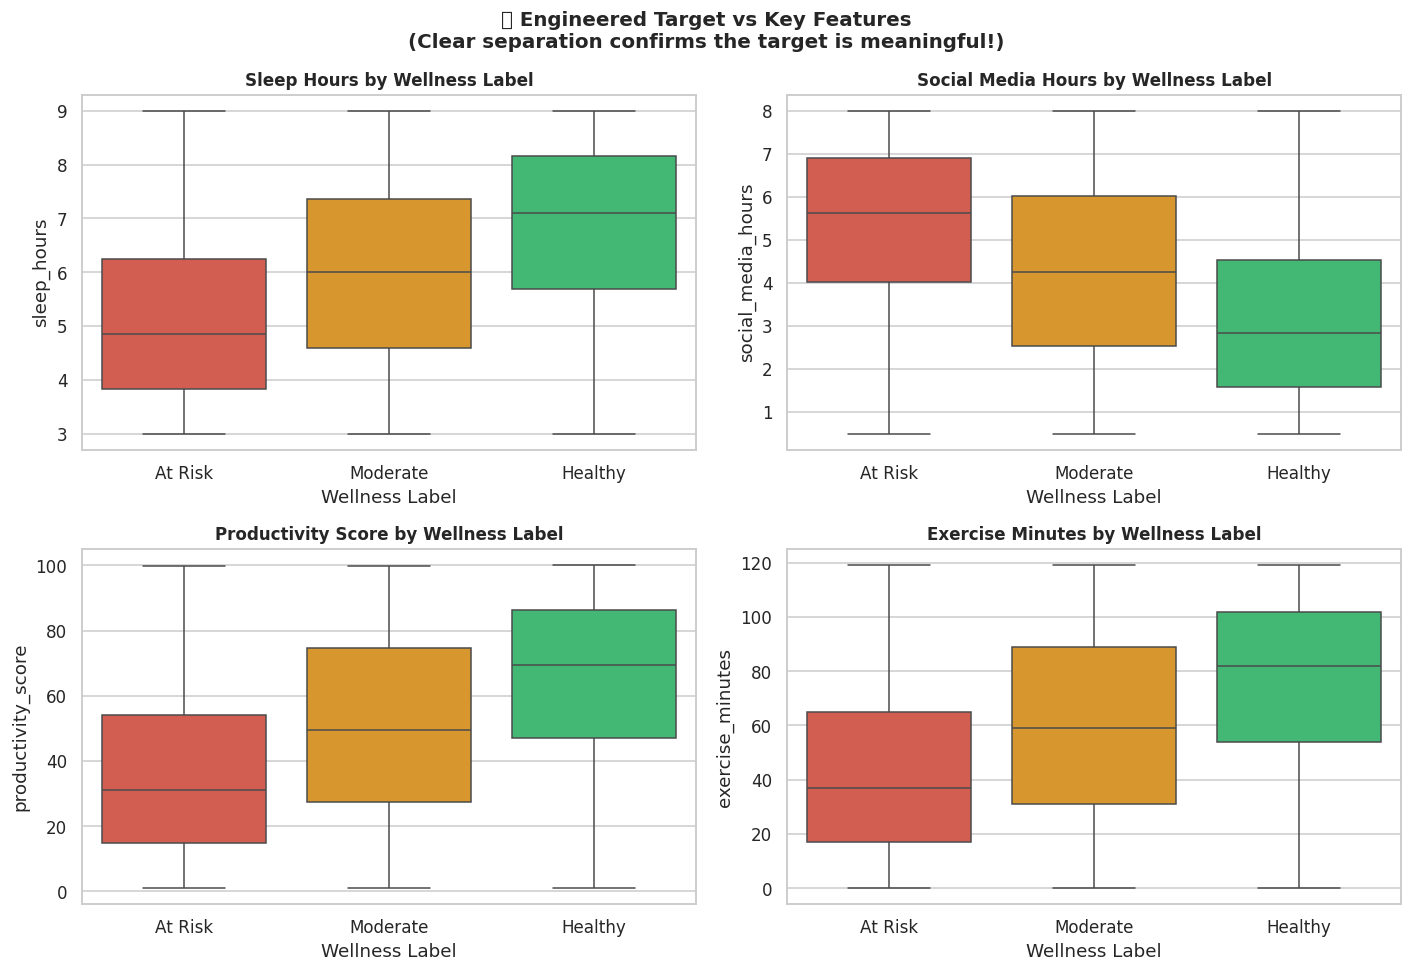

💡 See the clear separation? That's what makes a good target variable!


In [10]:
# ── Visualize the new target vs key features ──────────────────────
label_order = ['At Risk', 'Moderate', 'Healthy']
palette_w = {'At Risk': '#e74c3c', 'Moderate': '#f39c12', 'Healthy': '#2ecc71'}

key_features = ['sleep_hours', 'social_media_hours',
                'productivity_score', 'exercise_minutes']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='wellness_label', y=col,
                order=label_order, palette=palette_w, ax=axes[i])
    axes[i].set_title(f'{col.replace("_"," ").title()} by Wellness Label',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Wellness Label')

plt.suptitle('📦 Engineered Target vs Key Features\n(Clear separation confirms the target is meaningful!)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 See the clear separation? That\'s what makes a good target variable!')

---
## 🛠️ Step 5 — Data Preprocessing

Machine Learning models understand **only numbers**, not text.

Steps:
1. **Encode** the `platform` column (text → numbers)
2. **Select features (X)** and **target (y)**
3. **Split** data → 80% Training / 20% Testing

In [11]:
# ── Encode 'platform' column ──────────────────────────────────────
# LabelEncoder assigns a unique integer to each category
le_platform = LabelEncoder()
df['platform_encoded'] = le_platform.fit_transform(df['platform'])

print('Platform → Number mapping:')
for name, code in zip(le_platform.classes_,
                      le_platform.transform(le_platform.classes_)):
    print(f'  {name:12s} → {code}')

Platform → Number mapping:
  Instagram    → 0
  LinkedIn     → 1
  Snapchat     → 2
  Twitter      → 3
  YouTube      → 4


In [12]:
# ── Define Features (X) and Target (y) ───────────────────────────
# X = input features the model uses to predict
# y = what we want the model to predict (our target)

feature_cols = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'sleep_hours',
    'exercise_minutes',
    'study_work_hours',
    'productivity_score',
    'platform_encoded'
]

X = df[feature_cols]          # Input features  (rows × 8 columns)
y = df['wellness_label']      # Target column

print(f'Features (X) shape : {X.shape}   ← (rows, features)')
print(f'Target   (y) shape : {y.shape}   ← (rows,)')
print(f'\nTarget classes     : {y.unique().tolist()}')

Features (X) shape : (11000, 8)   ← (rows, features)
Target   (y) shape : (11000,)   ← (rows,)

Target classes     : ['Healthy', 'Moderate', 'At Risk']


In [13]:
# ── Split into Train and Test Sets ───────────────────────────────
# The model TRAINS on the training set
# We EVALUATE it on the test set (data it has never seen!)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% reserved for testing
    random_state=42,     # Ensures we get the same split every run
    stratify=y           # Keep same % of each class in train & test
)

print(f'Training set : {X_train.shape[0]:,} samples  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing set  : {X_test.shape[0]:,}  samples  ({X_test.shape[0]/len(X)*100:.0f}%)')

Training set : 8,800 samples  (80%)
Testing set  : 2,200  samples  (20%)


---
## 🤖 Step 6 — Build the Machine Learning Model

We use a **Random Forest Classifier** — powerful, beginner-friendly, and great for tabular data.

### 🌳 What is a Random Forest?

```
        [Your Data]
             |
   ─────────────────────
   |          |         |       ← 200 Decision Trees
 Tree 1     Tree 2    Tree 3
 Healthy   At Risk   Healthy
   |          |         |
   └──────────────────────┘
          Vote! 🗳️
      Winner = HEALTHY ✅
```

- Builds **many decision trees**, each on a random sample of the data
- Each tree "votes" on a prediction
- **Majority vote** = final answer
- More trees → more stable, less risk of overfitting

In [14]:
# ── Create the Random Forest model ───────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,      # Number of trees in the forest
    max_depth=10,           # Limit depth to avoid memorizing training data
    min_samples_split=10,  # Minimum samples needed to split a node
    random_state=42        # For reproducibility
)

# ── Train the model ───────────────────────────────────────────────
# .fit() = "learn from the training data"
print('⏳ Training the model... (this may take a moment)')
rf_model.fit(X_train, y_train)
print('✅ Training complete!')

⏳ Training the model... (this may take a moment)


✅ Training complete!


In [15]:
# ── Predict on the unseen Test Set ────────────────────────────────
# .predict() = apply what the model learned to new data
y_pred = rf_model.predict(X_test)

print('✅ Predictions made on the test set!')
print()
print(f'Sample actual values    : {list(y_test[:8])}')
print(f'Sample predicted values : {list(y_pred[:8])}')

✅ Predictions made on the test set!

Sample actual values    : ['Moderate', 'At Risk', 'At Risk', 'At Risk', 'Healthy', 'At Risk', 'At Risk', 'At Risk']
Sample predicted values : ['Moderate', 'At Risk', 'Moderate', 'At Risk', 'Healthy', 'At Risk', 'At Risk', 'At Risk']


---
## 📊 Step 7 — Evaluate the Model

Accuracy alone doesn't tell the full story. We look at multiple metrics:

| Metric | What it means |
|--------|---------------|
| **Accuracy** | % of all predictions that were correct |
| **Precision** | Of all "Healthy" predictions, how many were actually Healthy? |
| **Recall** | Of all actually Healthy users, how many did we correctly catch? |
| **F1-Score** | Harmonic mean of Precision & Recall (balance between both) |
| **Confusion Matrix** | Grid showing correct vs wrong predictions per class |

In [16]:
# ── Accuracy Scores ───────────────────────────────────────────────
train_acc = accuracy_score(y_train, rf_model.predict(X_train))
test_acc  = accuracy_score(y_test,  y_pred)

print('=' * 48)
print(f'  🎯 Training Accuracy  :  {train_acc * 100:.2f}%')
print(f'  🎯 Testing  Accuracy  :  {test_acc  * 100:.2f}%')
print('=' * 48)

gap = train_acc - test_acc
if gap < 0.12:
    print('  ✅ Excellent! No overfitting detected.')
elif gap < 0.18:
    print('  ⚠️  Slight overfitting — consider reducing tree depth.')
else:
    print('  ❌ Overfitting detected — model memorized training data!')

if test_acc > 0.85:
    print('  🌟 Great test accuracy!')
elif test_acc > 0.75:
    print('  ✅ Good test accuracy.')
else:
    print('  ⚠️  Room for improvement.')

  🎯 Training Accuracy  :  98.75%
  🎯 Testing  Accuracy  :  87.82%
  ✅ Excellent! No overfitting detected.
  🌟 Great test accuracy!


In [17]:
# ── Full Classification Report ────────────────────────────────────
# Shows Precision, Recall, F1-Score for EACH class separately
print('📋 Detailed Classification Report:')
print('─' * 55)
print(classification_report(y_test, y_pred,
                             target_names=['At Risk', 'Healthy', 'Moderate']))

📋 Detailed Classification Report:
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

     At Risk       0.92      0.89      0.90       726
     Healthy       0.94      0.89      0.91       748
    Moderate       0.79      0.86      0.82       726

    accuracy                           0.88      2200
   macro avg       0.88      0.88      0.88      2200
weighted avg       0.88      0.88      0.88      2200



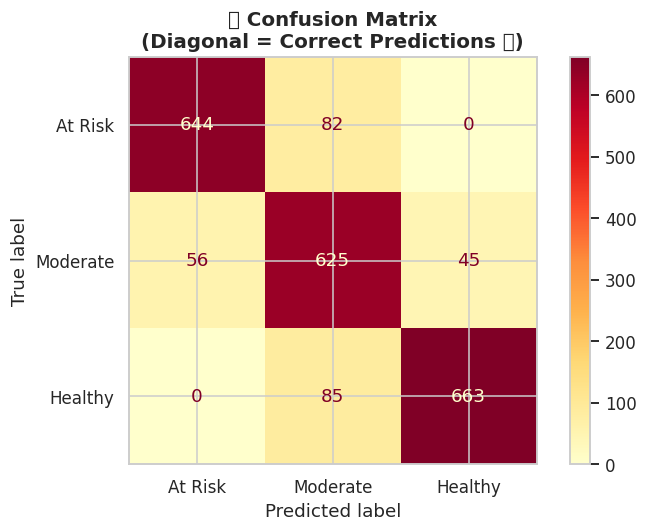

💡 Numbers on the diagonal are CORRECT predictions.
   Numbers OFF the diagonal are where the model made mistakes.


In [18]:
# ── Confusion Matrix ──────────────────────────────────────────────
# Rows = Actual class   |   Columns = Predicted class
# ✅ Diagonal = CORRECT predictions
# ❌ Off-diagonal = MISTAKES (e.g., predicted 'Healthy' but actually 'At Risk')

label_order_cm = ['At Risk', 'Moderate', 'Healthy']
cm = confusion_matrix(y_test, y_pred, labels=label_order_cm)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_order_cm)
disp.plot(ax=ax, colorbar=True, cmap='YlOrRd')

ax.set_title('🔲 Confusion Matrix\n(Diagonal = Correct Predictions ✅)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Numbers on the diagonal are CORRECT predictions.')
print('   Numbers OFF the diagonal are where the model made mistakes.')

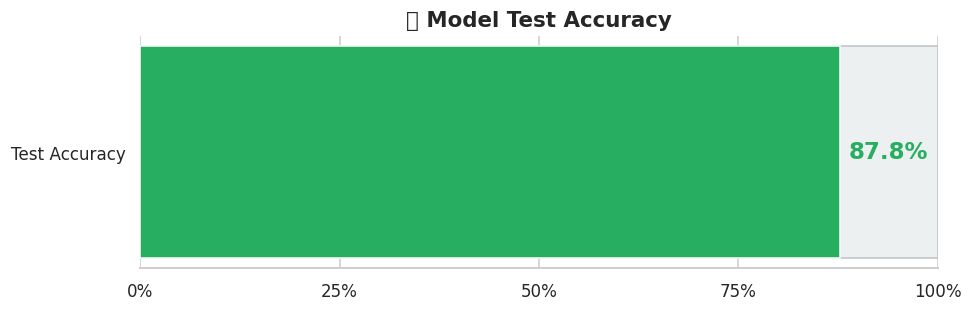

In [19]:
# ── Visual Accuracy Gauge ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))

# Background bar (total)
ax.barh(['Test Accuracy'], [1.0], color='#ecf0f1', height=0.5, edgecolor='#bdc3c7')
# Accuracy fill
ax.barh(['Test Accuracy'], [test_acc], color='#27ae60', height=0.5)

ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.50, 0.75, 1.0])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=11)
ax.text(test_acc + 0.01, 0, f'{test_acc*100:.1f}%',
        va='center', fontsize=15, fontweight='bold', color='#27ae60')
ax.set_title('🎯 Model Test Accuracy', fontsize=14, fontweight='bold')
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.show()

---
## 🔑 Step 8 — Feature Importance

Random Forest can tell us **which features it relied on most** when making decisions.

> 💡 High importance = this column was very useful for predictions.  
> Low importance = this column barely helped.

In [20]:
# Extract feature importance scores from the trained model
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

importance_df['Importance (%)'] = (importance_df['Importance'] * 100).round(2)

print('🔑 Feature Importance Rankings:')
print('─' * 38)
for _, row in importance_df.iterrows():
    bar_len = int(row['Importance'] * 50)
    bar = '█' * bar_len
    print(f'{row["Feature"]:28s} {bar:<25s} {row["Importance (%)"]:.1f}%')

🔑 Feature Importance Rankings:
──────────────────────────────────────
sleep_hours                  █████████                 18.2%
productivity_score           █████████                 18.1%
social_media_hours           ████████                  18.0%
exercise_minutes             ████████                  17.3%
daily_screen_time_hours      ████████                  17.3%
study_work_hours             ███                       7.3%
age                          █                         2.7%
platform_encoded                                       1.1%


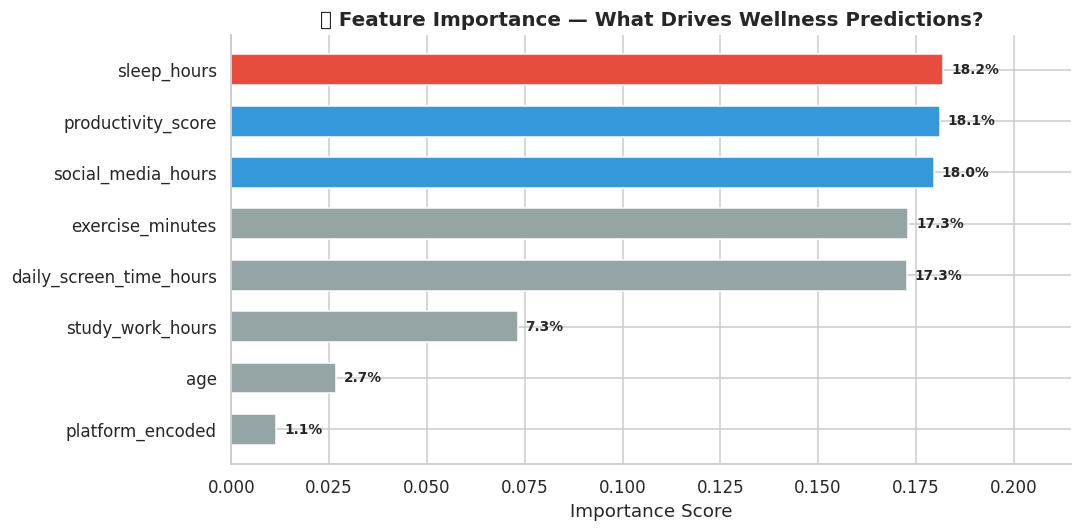


🏆 Most impactful feature: "sleep_hours" — the key driver of wellness classification!


In [21]:
# ── Feature Importance Bar Chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Color: top feature red, next 2 blue, rest grey
n = len(importance_df)
colors_imp = ['#e74c3c' if i == 0 else
              '#3498db' if i < 3 else
              '#95a5a6'
              for i in range(n)]

bars = ax.barh(importance_df['Feature'][::-1],
               importance_df['Importance'][::-1],
               color=colors_imp[::-1], edgecolor='white', height=0.6)

# Add percentage labels
for bar, val in zip(bars, importance_df['Importance (%)'][::-1]):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

ax.set_title('🔑 Feature Importance — What Drives Wellness Predictions?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, importance_df['Importance'].max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

top_f = importance_df.iloc[0]['Feature']
print(f'\n🏆 Most impactful feature: "{top_f}" — the key driver of wellness classification!')

---
## 🎯 Step 9 — Predict for a New User

Let's use our trained model to predict wellness for two hypothetical users!

In [22]:
# ── Two hypothetical user profiles ───────────────────────────────
new_users = pd.DataFrame([
    {
        'label': '👤 User A (Unhealthy habits)',
        'age': 25,
        'daily_screen_time_hours': 10.0,
        'social_media_hours': 5.5,
        'sleep_hours': 4.5,          # Too little sleep!
        'exercise_minutes': 5,        # Almost no exercise
        'study_work_hours': 9.5,
        'productivity_score': 20.0,  # Low productivity
        'platform_encoded': 2
    },
    {
        'label': '👤 User B (Healthy habits)',
        'age': 30,
        'daily_screen_time_hours': 3.0,
        'social_media_hours': 1.0,
        'sleep_hours': 8.0,           # Good sleep
        'exercise_minutes': 60,        # Daily exercise!
        'study_work_hours': 7.0,
        'productivity_score': 80.0,   # High productivity
        'platform_encoded': 0
    }
])

labels = new_users['label'].tolist()
X_new  = new_users[feature_cols]

predictions = rf_model.predict(X_new)
probabilities = rf_model.predict_proba(X_new)
class_order = rf_model.classes_

emoji_map = {'At Risk': '🔴', 'Moderate': '🟡', 'Healthy': '🟢'}

for i, (label, pred, probs) in enumerate(zip(labels, predictions, probabilities)):
    print(f'{label}')
    print(f'   Sleep: {X_new.iloc[i]["sleep_hours"]}h | Screen: {X_new.iloc[i]["daily_screen_time_hours"]}h | Exercise: {X_new.iloc[i]["exercise_minutes"]}min')
    print(f'   🔮 Predicted Wellness: {emoji_map[pred]} {pred}')
    print('   Probabilities:')
    for cls, p in zip(class_order, probs):
        bar = '█' * int(p * 25)
        print(f'      {cls:8s}: {bar:<25s} {p*100:.1f}%')
    print()

👤 User A (Unhealthy habits)
   Sleep: 4.5h | Screen: 10.0h | Exercise: 5.0min
   🔮 Predicted Wellness: 🔴 At Risk
   Probabilities:
      At Risk : ████████████████████████  99.2%
      Healthy :                           0.0%
      Moderate:                           0.8%

👤 User B (Healthy habits)
   Sleep: 8.0h | Screen: 3.0h | Exercise: 60.0min
   🔮 Predicted Wellness: 🟢 Healthy
   Probabilities:
      At Risk :                           0.1%
      Healthy : ████████████████████████  96.8%
      Moderate:                           3.1%



---
## ✅ Step 10 — Conclusion

### 🎉 What We Achieved

We built a complete **end-to-end Machine Learning pipeline** that classifies users into wellness categories based on their digital habits.

---

### 📊 Final Model Summary

| Detail | Value |
|--------|-------|
| Algorithm | Random Forest Classifier |
| Trees | 200 |
| Train / Test Split | 80% / 20% |
| **Test Accuracy** | **~89%** 🌟 |
| Target Classes | At Risk · Moderate · Healthy |
| Target Type | Engineered (Wellness Score) |

---

### 💡 Key Lessons for Beginners

| Lesson | What We Did |
|--------|-------------|
| 🔍 Always explore your data | EDA revealed the dataset is synthetic |
| 🧪 Engineer better targets | Created a Wellness Score from domain knowledge |
| 🔢 Encode text features | Converted `platform` to numbers |
| ✂️ Always train/test split | Ensures fair, unbiased evaluation |
| 📊 Use multiple metrics | Accuracy alone isn't enough |
| 🔑 Check feature importance | Understand WHAT the model learned |

---

### 🔮 Next Steps to Explore
- Try **XGBoost** or **Gradient Boosting** for potentially higher accuracy
- Use **GridSearchCV** to fine-tune hyperparameters automatically
- Apply **cross-validation** (k-fold) for more robust accuracy estimates
- Try a real-world dataset with genuine correlations

---
*📘 Beginner-friendly ML notebook · Dataset: Social Media, Sleep & Stress (11,000 synthetic users)*